First 5 rows:
    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0    

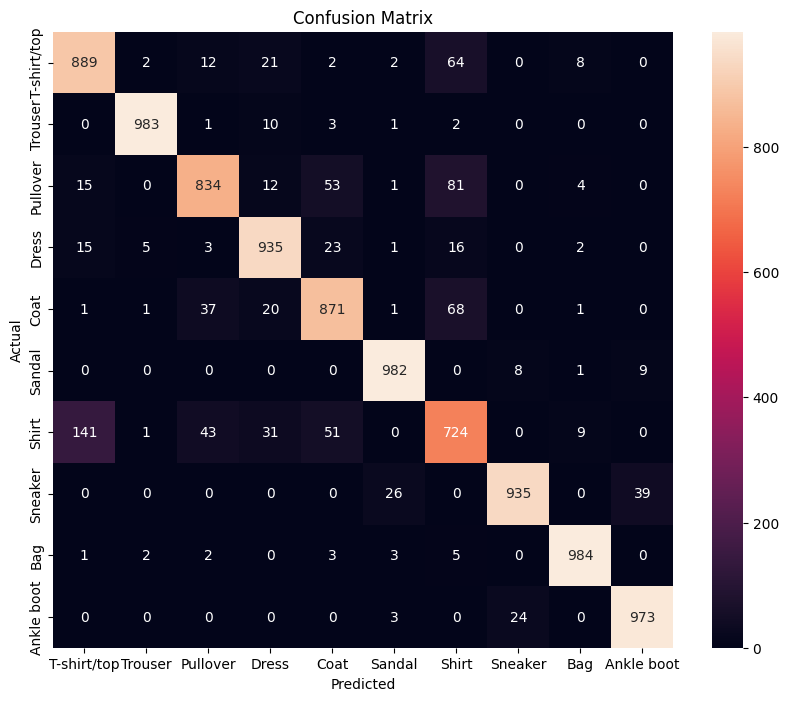

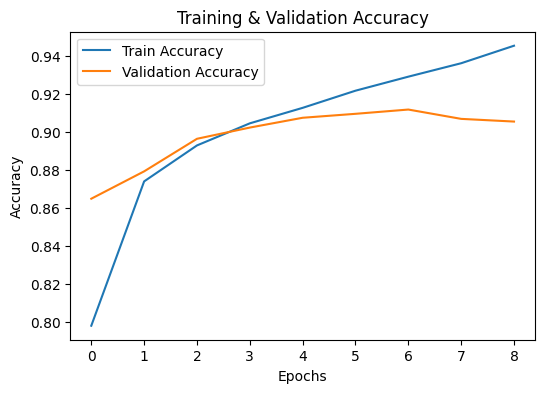

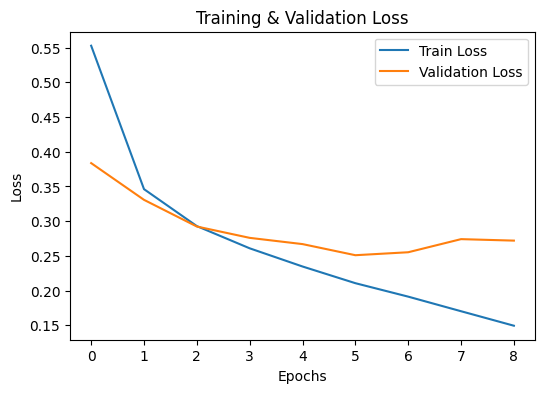

In [2]:
# Fashion-MNIST Image Classification using CNN (3 Conv Layers + Plots + Confusion Matrix)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------------
# 1. Load Dataset
# -------------------------------
train_data = pd.read_csv("fashion-mnist_train.csv")
test_data = pd.read_csv("fashion-mnist_test.csv")

print("First 5 rows:\n", train_data.head())

# -------------------------------
# 2. Features & Target
# -------------------------------
X_train = train_data.iloc[:, 1:].values                   # Extract input features (pixel values) → all columns except first
y_train = train_data.iloc[:, 0].values                    # Extract labels (class 0–9) → first column  

# Same for test data

X_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values   

# -------------------------------
# 3. Normalization
# -------------------------------
# Scale pixel values from range [0, 255] → [0, 1]
# Helps faster training and better convergence

X_train = X_train / 255.0
X_test = X_test / 255.0

# -------------------------------
# 4. Reshape for CNN (28x28x1)
# -------------------------------
# Convert 1D flat vectors (784,) i.e. of 784 elements, into 2D image format (28x28) with 1 channel                     (tuple with ONE element means (number,))
# CNN requires input in (height, width, channels) format

X_train = X_train.reshape(-1, 28, 28, 1)                                 # -1 means automatically/dynamically figure out dimension(size/number of samples)
X_test = X_test.reshape(-1, 28, 28, 1)


# -------------------------------
# 5. Build CNN Model
# -------------------------------
model = keras.Sequential([
    keras.Input(shape=(28,28,1)),

    # Convolution Block 1
    layers.Conv2D(32, (3,3), activation='relu'),             # (3,3) is kernel (filter) size - The model looks at a 3×3 patch of the image at a time
    layers.MaxPooling2D(2,2),

    # Convolution Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Convolution Block 3
    layers.Conv2D(128, (3,3), activation='relu'),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(128, activation='relu'),

    # Output Layer (10 classes)
    layers.Dense(10, activation='softmax')
])

# -------------------------------
# 6. Compile Model
# -------------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
#  Early Stopping
# -------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# -------------------------------
# 7. Train Model
# -------------------------------
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks = [early_stop],
    verbose=1
)

# -------------------------------
# 8. Evaluate Model
# -------------------------------
loss, accuracy = model.evaluate(X_test, y_test)

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# -------------------------------
# 9. Results
# -------------------------------
print("\n===== MODEL PERFORMANCE =====")
print("Accuracy: ", accuracy)
print("Loss: ", loss)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1)

# Class Labels
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# -------------------------------
# 10. Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# 11. Accuracy Graph
# -------------------------------
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.show()

# -------------------------------
# 12. Loss Graph
# -------------------------------
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.show()